In [1]:
# Bibliotecas
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import utils as np_utils

In [3]:
(X_treinamento, y_treinamento), (X_teste, y_teste) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
X_treinamento.shape, X_teste.shape

((60000, 28, 28), (10000, 28, 28))

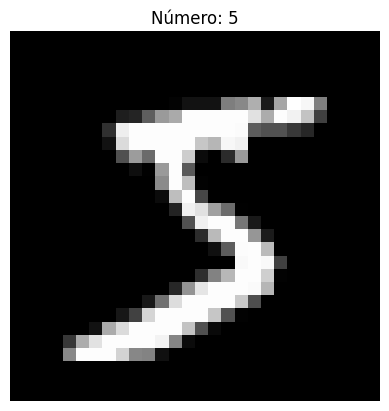

In [7]:
plt.imshow(X_treinamento[0], cmap='gray')
plt.title(f"Número: {y_treinamento[0]}")
plt.axis("off")
plt.show()

In [10]:
# Redimensionando as imagens para o formato aceito pela CNN
X_treinamento = X_treinamento.reshape(X_treinamento.shape[0], 28, 28, 1)
X_teste = X_teste.reshape(X_teste.shape[0], 28, 28, 1)

# Convertendo para float
X_treinamento = X_treinamento.astype('float32')
X_teste = X_teste.astype('float32')

# Normalizando os pixels
X_treinamento /= 255
X_teste /= 255

# Convertendo as classes para o formato categórico
y_treinamento = np_utils.to_categorical(y_treinamento, 10)
y_teste = np_utils.to_categorical(y_teste, 10)

In [11]:
X_treinamento.shape, X_teste.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [12]:
y_treinamento.shape

(60000, 10)

In [13]:
rede_neural = Sequential()  # Criação da rede neural

rede_neural.add(InputLayer(shape=(28, 28, 1)))  # Camada de entrada (28x28 pixels e 1 canal)

rede_neural.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))  # 1ª camada convolucional
rede_neural.add(BatchNormalization())  # Normalização dos dados
rede_neural.add(MaxPooling2D(pool_size=(2,2)))  # Redução das dimensões da imagem

rede_neural.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))  # 2ª camada convolucional
rede_neural.add(BatchNormalization())  # Nova normalização
rede_neural.add(MaxPooling2D(pool_size=(2,2)))  # Nova redução das dimensões

rede_neural.add(Flatten())  # Converte a matriz em um vetor

rede_neural.add(Dense(units=128, activation='relu'))  # Camada totalmente conectada
rede_neural.add(Dropout(0.2))  # Desativa 20% dos neurônios

rede_neural.add(Dense(units=128, activation='relu'))  # Segunda camada totalmente conectada
rede_neural.add(Dropout(0.2))  # Novo Dropout

rede_neural.add(Dense(units=10, activation='softmax'))  # Camada de saída com 10 classes

In [14]:
rede_neural.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,154 (508.41 KB)

 Trainable params: 130,026 (507.91 KB)

 Non-trainable params: 128 (512.00 B)

In [15]:
rede_neural.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [16]:
historico = rede_neural.fit(X_treinamento, y_treinamento, batch_size=128, epochs=5, validation_data=(X_teste, y_teste))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 138ms/step - accuracy: 0.9233 - loss: 0.2510 - val_accuracy: 0.4848 - val_loss: 1.5636
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 144ms/step - accuracy: 0.9786 - loss: 0.0686 - val_accuracy: 0.4494 - val_loss: 2.8630
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 135ms/step - accuracy: 0.9842 - loss: 0.0524 - val_accuracy: 0.5126 - val_loss: 2.9350
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - accuracy: 0.9878 - loss: 0.0397 - val_accuracy: 0.7317 - val_loss: 0.9331
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.9898 - loss: 0.0331 - val_accuracy: 0.5826 - val_loss: 2.1256


In [19]:
resultado = rede_neural.evaluate(X_teste, y_teste)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5826 - loss: 2.1256


In [20]:
resultado[0] # erro

2.1255578994750977

In [21]:
resultado[1] # Acuracia

0.5825999975204468